# Data Analysis with PySpark and SparkSQL


PySpark is the Python API for Apache Spark, a distributed computing system designed for handling large-scale data processing. Its ability to perform computations across multiple nodes makes it an ideal choice for Big Data scenarios, where data sets can reach terabytes or even petabytes in size. PySpark allows data scientists and analysts to harness the power of distributed computing, scaling up their workflows and processing capabilities significantly.


To illustrate the strengths of both PySpark and Pandas, we will utilize a sample COVID-19 data set containing daily cases, deaths, and vaccinations across various continents.


## 1. Installing necessary libraries

- First, let's install the necessary libraries if they are not already installed.


In [44]:
!pip install pyspark
!pip install findspark
!pip install pandas

^C


## 2. Initializing a Spark session


In [45]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [46]:
import findspark  # This helps us find and use Apache Spark
findspark.init()  # Initialize findspark to locate Spark

In [47]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, LongType, DateType
import pandas as pd

# Initialize a Spark Session
spark = SparkSession \
    .builder \
    .appName("COVID-19 Data Analysis") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Check if the Spark Session is active
if 'spark' in locals() and isinstance(spark, SparkSession):
    print("SparkSession is active and ready to use.")
else:
    print("SparkSession is not active. Please create a SparkSession.")

SparkSession is active and ready to use.


## 3. Importing data into Pandas from various sources


In [48]:
vaccination_data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/KpHDlIzdtR63BdTofl1mOg/owid-covid-latest.csv')

vaccination_data.head(5)

,iso_code,continent,location,last_updated_date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2024-08-04,235214.0,0.0,0.000,7998.0,0.0,0.0,...,NaN,37.746,0.50,64.83,0.511,4.112877e+07,NaN,NaN,NaN,NaN
1,OWID_AFR,NaN,Africa,2024-08-04,13145380.0,36.0,5.143,259117.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
2,ALB,Europe,Albania,2024-08-04,335047.0,0.0,0.000,3605.0,0.0,0.0,...,51.2,NaN,2.89,78.57,0.795,2.842318e+06,NaN,NaN,NaN,NaN
3,DZA,Africa,Algeria,2024-08-04,272139.0,18.0,2.571,6881.0,0.0,0.0,...,30.4,83.741,1.90,76.88,0.748,4.490323e+07,NaN,NaN,NaN,NaN
4,ASM,Oceania,American Samoa,2024-08-04,8359.0,0.0,0.000,34.0,0.0,0.0,...,NaN,NaN,NaN,73.74,NaN,4.429500e+04,NaN,NaN,NaN,NaN


## 4. Displaying the first five records


In [49]:
print("Displaying the first 5 records of the vaccination data:")
columns_to_display = ['continent', 'total_cases', 'total_deaths', 'total_vaccinations', 'population']

print(vaccination_data[columns_to_display].head())

Displaying the first 5 records of the vaccination data:
  continent  total_cases  total_deaths  total_vaccinations    population
0      Asia     235214.0        7998.0                 NaN  4.112877e+07
1       NaN   13145380.0      259117.0                 NaN  1.426737e+09
2    Europe     335047.0        3605.0                 NaN  2.842318e+06
3    Africa     272139.0        6881.0                 NaN  4.490323e+07
4   Oceania       8359.0          34.0                 NaN  4.429500e+04


## 5. Converting the Pandas DataFrame to a Spark DataFrame


Let\'s convert the Pandas DataFrame, which contains our COVID-19 vaccination data, into a Spark DataFrame. This conversion is crucial as it allows us to utilize Spark\'s distributed computing capabilities, enabling us to handle larger datasets and perform operations in a more efficient manner.


In [50]:
# Convert to Spark DataFrame directly
# Define the schema
schema = StructType([
    StructField("continent", StringType(), True),
    StructField("total_cases", LongType(), True),
    StructField("total_deaths", LongType(), True),
    StructField("total_vaccinations", LongType(), True),
    StructField("population", LongType(), True)
])

# Convert the columns to the appropriate data types
vaccination_data['continent'] = vaccination_data['continent'].astype(str)  # Ensures continent is a string
vaccination_data['total_cases'] = vaccination_data['total_cases'].fillna(0).astype('int64')  # Fill NaNs and convert to int
vaccination_data['total_deaths'] = vaccination_data['total_deaths'].fillna(0).astype('int64')  # Fill NaNs and convert to int
vaccination_data['total_vaccinations'] = vaccination_data['total_vaccinations'].fillna(0).astype('int64')  # Fill NaNs and convert to int
vaccination_data['population'] = vaccination_data['population'].fillna(0).astype('int64')  # Fill NaNs and convert to int

spark_df = spark.createDataFrame(vaccination_data[schema.fieldNames()])  # Use only the specified fields
# Show the Spark DataFrame
spark_df.show()

c:\Users\ISSHITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


+-------------+-----------+------------+------------------+----------+
|    continent|total_cases|total_deaths|total_vaccinations|population|
+-------------+-----------+------------+------------------+----------+
|         Asia|     235214|        7998|                 0|  41128772|
|          nan|   13145380|      259117|                 0|1426736614|
|       Europe|     335047|        3605|                 0|   2842318|
|       Africa|     272139|        6881|                 0|  44903228|
|      Oceania|       8359|          34|                 0|     44295|
|       Europe|      48015|         159|                 0|     79843|
|       Africa|     107481|        1937|                 0|  35588996|
|North America|       3904|          12|                 0|     15877|
|North America|       9106|         146|                 0|     93772|
|South America|   10101218|      130663|                 0|  45510324|
|         Asia|     452273|        8777|                 0|   2780472|
|North

## 6. Checking the structure of the Spark DataFrame


In [51]:
print("Schema of the Spark DataFrame:")
spark_df.printSchema()

Schema of the Spark DataFrame:
root
 |-- continent: string (nullable = true)
 |-- total_cases: long (nullable = true)
 |-- total_deaths: long (nullable = true)
 |-- total_vaccinations: long (nullable = true)
 |-- population: long (nullable = true)



## 7. Basic data exploration


### 7.1 Viewing DataFrame contents


In [52]:
# List the names of the columns you want to display
columns_to_display = ['continent', 'total_cases', 'total_deaths', 'total_vaccinations', 'population']
# Display the first 5 records of the specified columns
spark_df.select(columns_to_display).show(5)

+---------+-----------+------------+------------------+----------+
|continent|total_cases|total_deaths|total_vaccinations|population|
+---------+-----------+------------+------------------+----------+
|     Asia|     235214|        7998|                 0|  41128772|
|      nan|   13145380|      259117|                 0|1426736614|
|   Europe|     335047|        3605|                 0|   2842318|
|   Africa|     272139|        6881|                 0|  44903228|
|  Oceania|       8359|          34|                 0|     44295|
+---------+-----------+------------+------------------+----------+
only showing top 5 rows


### 7.2 Picking specific columns


In [53]:
print("Displaying the 'continent' and 'total_cases' columns:")
# Show only the 'continent' and 'total_cases' columns
spark_df.select('continent', 'total_cases').show(5)

Displaying the 'continent' and 'total_cases' columns:
+---------+-----------+
|continent|total_cases|
+---------+-----------+
|     Asia|     235214|
|      nan|   13145380|
|   Europe|     335047|
|   Africa|     272139|
|  Oceania|       8359|
+---------+-----------+
only showing top 5 rows


### 7.3 Sifting Through Data


In [54]:
print("Filtering records where 'total_cases' is greater than 1,000,000:")
 # Show records with more than 1 million total cases
spark_df.filter(spark_df['total_cases'] > 1000000).show(5)

Filtering records where 'total_cases' is greater than 1,000,000:
+-------------+-----------+------------+------------------+----------+
|    continent|total_cases|total_deaths|total_vaccinations|population|
+-------------+-----------+------------+------------------+----------+
|          nan|   13145380|      259117|                 0|1426736614|
|South America|   10101218|      130663|                 0|  45510324|
|          nan|  301499099|     1637249|        9104304615|4721383370|
|      Oceania|   11861161|       25236|                 0|  26177410|
|       Europe|    6082444|       22534|                 0|   8939617|
+-------------+-----------+------------+------------------+----------+
only showing top 5 rows


## 8. Calculating the death percentage


In [55]:
from pyspark.sql import functions as F

spark_df_with_percentage = spark_df.withColumn(
    'death_percentage',
    (spark_df['total_deaths'] / spark_df['population']) * 100
)
spark_df_with_percentage = spark_df_with_percentage.withColumn(
    'death_percentage',
    F.concat(
        # Format to 2 decimal places
        F.format_number(spark_df_with_percentage['death_percentage'], 2),
        # Append the percentage symbol
        F.lit('%')
    )
)
columns_to_display = ['total_deaths', 'population', 'death_percentage', 'continent', 'total_vaccinations', 'total_cases']
spark_df_with_percentage.select(columns_to_display).show(5)

+------------+----------+----------------+---------+------------------+-----------+
|total_deaths|population|death_percentage|continent|total_vaccinations|total_cases|
+------------+----------+----------------+---------+------------------+-----------+
|        7998|  41128772|           0.02%|     Asia|                 0|     235214|
|      259117|1426736614|           0.02%|      nan|                 0|   13145380|
|        3605|   2842318|           0.13%|   Europe|                 0|     335047|
|        6881|  44903228|           0.02%|   Africa|                 0|     272139|
|          34|     44295|           0.08%|  Oceania|                 0|       8359|
+------------+----------+----------------+---------+------------------+-----------+
only showing top 5 rows


## 9. Grouping and summarizing


 Let\'s calculate the total number of deaths per continent using the data in our Spark DataFrame. Grouping and summarizing data is a crucial aspect of data analysis, as it allows us to aggregate information and identify trends across different categories.


In [56]:
print("Calculating the total deaths per continent:")
# Group by continent and sum total death rates
spark_df.groupby(['continent']).agg({"total_deaths": "SUM"}).show()

Calculating the total deaths per continent:
+-------------+-----------------+
|    continent|sum(total_deaths)|
+-------------+-----------------+
|       Europe|          2102483|
|       Africa|           259117|
|          nan|         22430618|
|North America|          1671178|
|South America|          1354187|
|      Oceania|            32918|
|         Asia|          1637249|
+-------------+-----------------+



c:\Users\ISSHITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


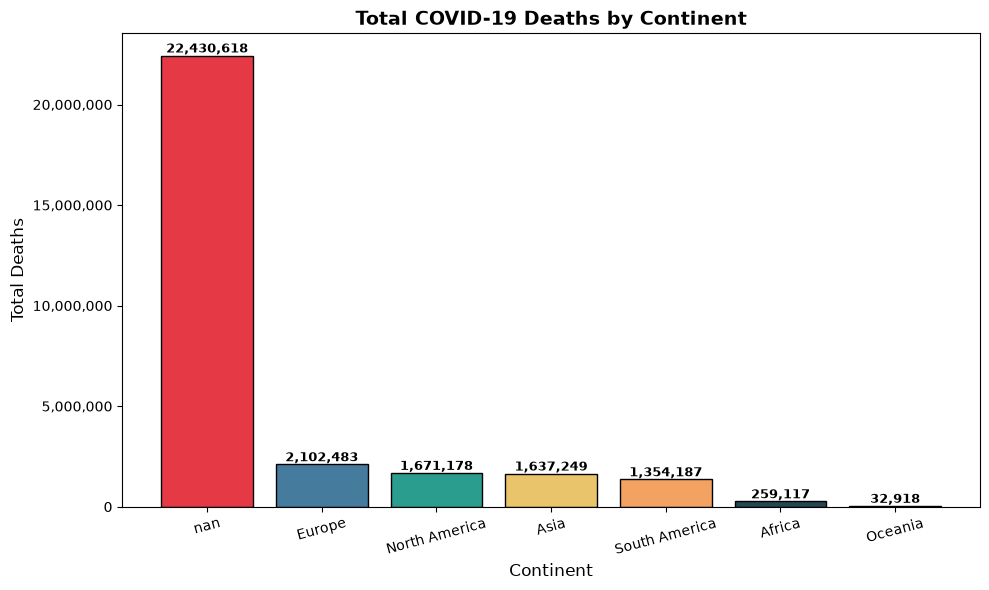

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

continent_deaths = (
    spark_df
    .groupby(['continent'])
    .agg({"total_deaths": "sum"})
    .dropna(subset=['continent'])
)

pdf = continent_deaths.toPandas().sort_values("sum(total_deaths)", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    pdf['continent'],
    pdf['sum(total_deaths)'],
    color=['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261','#264653','#8ecae6'],
    edgecolor='black'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title("Total COVID-19 Deaths by Continent", fontsize=14, fontweight='bold')
ax.set_xlabel("Continent", fontsize=12)
ax.set_ylabel("Total Deaths", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 10. Exploring user-defined functions (UDFs)


The line `spark.udf.register("convert_total_deaths", convert_total_deaths, IntegerType())` registers the UDF with Spark indicating that the function returns an integer, allowing us to use it in Spark SQL queries and DataFrame operations.


In [58]:
from pyspark.sql.types import StringType

# Function definition
def mortality_risk(total_cases, total_deaths):

    if total_cases == 0:
        return "Unknown"

    death_rate = (total_deaths / total_cases) * 100

    if death_rate < 1:
        return "Low"
    elif death_rate < 3:
        return "Moderate"
    else:
        return "High"

# Register the UDF with Spark
spark.udf.register("mortality_risk",mortality_risk,StringType())

<function __main__.mortality_risk(total_cases, total_deaths)>

## 11. Using Spark SQL


In [59]:
# Drop the existing temporary view if it exists
spark.sql("DROP VIEW IF EXISTS data_v")

# Create a new temporary view
spark_df.createTempView('data_v')

# Execute the SQL query using the UDF
spark.sql("""
SELECT continent,
       total_cases,
       total_deaths,
       mortality_risk(total_cases, total_deaths)
           AS risk_level
FROM data_v
""").show()

+-------------+-----------+------------+----------+
|    continent|total_cases|total_deaths|risk_level|
+-------------+-----------+------------+----------+
|         Asia|     235214|        7998|      High|
|          nan|   13145380|      259117|  Moderate|
|       Europe|     335047|        3605|  Moderate|
|       Africa|     272139|        6881|  Moderate|
|      Oceania|       8359|          34|       Low|
|       Europe|      48015|         159|       Low|
|       Africa|     107481|        1937|  Moderate|
|North America|       3904|          12|       Low|
|North America|       9106|         146|  Moderate|
|South America|   10101218|      130663|  Moderate|
|         Asia|     452273|        8777|  Moderate|
|North America|      44224|         292|       Low|
|          nan|  301499099|     1637249|       Low|
|      Oceania|   11861161|       25236|       Low|
|       Europe|    6082444|       22534|       Low|
|         Asia|     835757|       10353|  Moderate|
|North Ameri

In [60]:
#save the SQL result
death_rank_df = spark.sql("""SELECT continent,SUM(total_deaths) AS deaths,RANK() OVER (
           ORDER BY SUM(total_deaths) DESC) AS death_rank FROM data_v 
           GROUP BY continent
           """)

In [61]:
#view it 
death_rank_df.show()

+-------------+--------+----------+
|    continent|  deaths|death_rank|
+-------------+--------+----------+
|          nan|22430618|         1|
|       Europe| 2102483|         2|
|North America| 1671178|         3|
|         Asia| 1637249|         4|
|South America| 1354187|         5|
|       Africa|  259117|         6|
|      Oceania|   32918|         7|
+-------------+--------+----------+



c:\Users\ISSHITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


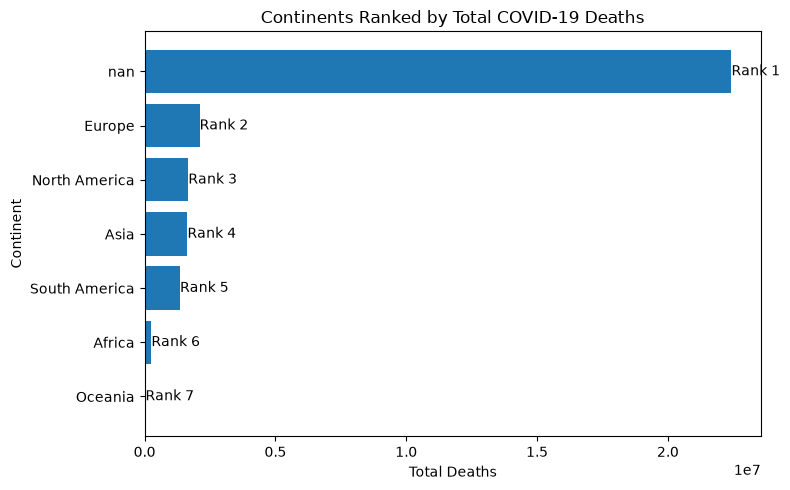

In [62]:
# convert it to Pandas for plotting
death_rank_pd = death_rank_df.toPandas()

plt.figure(figsize=(8,5))

bars = plt.barh(
    death_rank_pd["continent"],
    death_rank_pd["deaths"]
)

plt.xlabel("Total Deaths")
plt.ylabel("Continent")
plt.title("Continents Ranked by Total COVID-19 Deaths")

plt.gca().invert_yaxis()

for i, bar in enumerate(bars):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"Rank {death_rank_pd.loc[i, 'death_rank']}",
        va='center'
    )

plt.tight_layout()
plt.show()

## 12. Filtering the data


In [63]:
print("Displaying continent with total vaccinated more than 1 million:")
# SQL filtering
spark.sql("SELECT continent FROM data_v WHERE total_vaccinations > 1000000").show()

Displaying continent with total vaccinated more than 1 million:
+-------------+
|    continent|
+-------------+
|          nan|
|North America|
|       Europe|
|       Europe|
|          nan|
|          nan|
|          nan|
|         Asia|
|         Asia|
|       Europe|
|          nan|
|         Asia|
|      Oceania|
|          nan|
|          nan|
|          nan|
|          nan|
+-------------+



# 13. Case Fatality Rate Category

In [64]:
from pyspark.sql.types import StringType

def risk_category(total_cases, total_deaths):
    if total_cases == 0:
        return "Unknown"

    rate = (total_deaths / total_cases) * 100

    if rate < 1:
        return "Low"
    elif rate < 3:
        return "Moderate"
    else:
        return "High"

spark.udf.register("risk_category",risk_category,StringType())

<function __main__.risk_category(total_cases, total_deaths)>

In [65]:
spark_df.createOrReplaceTempView("covid")

spark.sql("""SELECT continent,total_cases, total_deaths,risk_category(total_cases,total_deaths) AS risk_level
        FROM covid LIMIT 10 """).show()

+-------------+-----------+------------+----------+
|    continent|total_cases|total_deaths|risk_level|
+-------------+-----------+------------+----------+
|         Asia|     235214|        7998|      High|
|          nan|   13145380|      259117|  Moderate|
|       Europe|     335047|        3605|  Moderate|
|       Africa|     272139|        6881|  Moderate|
|      Oceania|       8359|          34|       Low|
|       Europe|      48015|         159|       Low|
|       Africa|     107481|        1937|  Moderate|
|North America|       3904|          12|       Low|
|North America|       9106|         146|  Moderate|
|South America|   10101218|      130663|  Moderate|
+-------------+-----------+------------+----------+



In [66]:
spark.stop()